In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [107]:
df = pd.read_excel("World_development_mesurement.xlsx")
df

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,...,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,...,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,...,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,...,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,...,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699,NaN,NaN,NaN,Turks and Caicos Islands,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1,NaN,NaN,NaN,32427,0.911,NaN,NaN
2700,0.013,46.4%,NaN,United States,5.0,4.0,2132446.0,"$16,244,600,000,000",0.179,"$8,895",...,76.0,1.0,1,0.196,0.667,0.136,313873685,0.811,"$200,092,000,000","$126,573,000,000"
2701,0.015,41.9%,NaN,Uruguay,7.0,85.0,NaN,"$50,004,354,667",0.089,"$1,308",...,74.0,1.5,1,0.220,0.639,0.140,3395253,0.948,"$2,222,000,000","$1,028,000,000"
2702,0.020,61.9%,NaN,"Venezuela, RB",144.0,180.0,NaN,"$381,286,223,859",0.046,$593,...,72.0,1.0,1,0.288,0.652,0.060,29954782,0.889,"$904,000,000","$3,202,000,000"


In [108]:
#  FORCE CLEANING (critical for deployment)
df = df.replace({',': '', '$': '', '%': ''}, regex=True)
df = df.replace(['', ' ', 'NA', 'None'], np.nan)

# Convert everything except Country
for col in df.columns:
    if col != "Country":
        df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.fillna(0)

In [109]:
df.shape

(2704, 25)

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2704 non-null   float64
 1   Business Tax Rate       2704 non-null   float64
 2   CO2 Emissions           2704 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  2704 non-null   float64
 5   Ease of Business        2704 non-null   float64
 6   Energy Usage            2704 non-null   float64
 7   GDP                     2704 non-null   float64
 8   Health Exp % GDP        2704 non-null   float64
 9   Health Exp/Capita       2704 non-null   float64
 10  Hours to do Tax         2704 non-null   float64
 11  Infant Mortality Rate   2704 non-null   float64
 12  Internet Usage          2704 non-null   float64
 13  Lending Interest        2704 non-null   float64
 14  Life Expectancy Female  2704 non-null   

In [111]:
df.isnull().sum().sort_values(ascending=False)

Birth Rate                0
Business Tax Rate         0
CO2 Emissions             0
Country                   0
Days to Start Business    0
Ease of Business          0
Energy Usage              0
GDP                       0
Health Exp % GDP          0
Health Exp/Capita         0
Hours to do Tax           0
Infant Mortality Rate     0
Internet Usage            0
Lending Interest          0
Life Expectancy Female    0
Life Expectancy Male      0
Mobile Phone Usage        0
Number of Records         0
Population 0-14           0
Population 15-64          0
Population 65+            0
Population Total          0
Population Urban          0
Tourism Inbound           0
Tourism Outbound          0
dtype: int64

In [112]:
df.describe()

,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
count,2704.000000,2704.000000,2.704000e+03,2704.000000,2704.000000,2.704000e+03,2704.0,2704.000000,2704.0,2704.000000,...,2704.000000,2704.000000,2704.0,2704.000000,2704.000000,2704.000000,2.704000e+03,2704.000000,2704.0,2704.0
mean,0.021715,25.769194,1.118353e+05,25.413831,6.491124,5.098660e+04,0.0,0.056837,0.0,158.183802,...,63.119083,0.542419,1.0,0.278395,0.572754,0.067487,3.145729e+07,0.557540,0.0,0.0
std,0.012026,38.475618,5.491031e+05,49.575982,27.897875,2.143112e+05,0.0,0.032105,0.0,248.736248,...,17.170013,0.480360,0.0,0.131533,0.183091,0.051557,1.242894e+08,0.250804,0.0,0.0
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.887600e+04,0.000000,0.0,0.0
25%,0.012000,0.000000,1.500000e+02,0.000000,0.000000,0.000000e+00,0.0,0.039000,0.0,0.000000,...,59.000000,0.100000,1.0,0.184000,0.546000,0.031000,8.783360e+05,0.353000,0.0,0.0
50%,0.019000,15.400000,3.131500e+03,12.000000,0.000000,3.521000e+03,0.0,0.057000,0.0,76.000000,...,68.000000,0.500000,1.0,0.285500,0.631000,0.048000,5.800324e+06,0.557000,0.0,0.0
75%,0.030000,42.300000,4.256200e+04,34.250000,0.000000,2.347650e+04,0.0,0.076000,0.0,256.000000,...,73.000000,0.900000,1.0,0.395000,0.673000,0.105000,2.014089e+07,0.763000,0.0,0.0
max,0.053000,339.100000,8.286892e+06,694.000000,189.000000,2.727728e+06,0.0,0.225000,0.0,2600.000000,...,88.000000,2.900000,1.0,0.500000,0.858000,0.244000,1.350695e+09,1.000000,0.0,0.0


In [113]:
#num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include='object').columns

#num_cols, 
cat_cols

Index(['Country'], dtype='object')

In [114]:
df.select_dtypes(include='object').columns

Index(['Country'], dtype='object')

In [115]:
numeric_like_cols = [col for col in cat_cols if col != 'Country']

In [116]:
numeric_like_cols

[]

In [117]:
df_clean = df.copy()

numeric_like_cols = []
for col in cat_cols:
    if col != 'Country':
        df_clean[col] = (
            df_clean[col]
            .astype(str)
            .str.replace('$', '', regex=False)
            .str.replace(',', '', regex=False)
            .str.replace('%', '', regex=False)
            .str.strip()
        )
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        numeric_like_cols.append(col)

In [118]:
df_clean

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,0.0,87931.0,Algeria,0.0,0.0,26998.0,0.0,0.035,0.0,...,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,0.0,0.0
1,0.050,0.0,9542.0,Angola,0.0,0.0,7499.0,0.0,0.034,0.0,...,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,0.0,0.0
2,0.043,0.0,1617.0,Benin,0.0,0.0,1983.0,0.0,0.043,0.0,...,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,0.0,0.0
3,0.027,0.0,4276.0,Botswana,0.0,0.0,1836.0,0.0,0.047,0.0,...,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,0.0,0.0
4,0.046,0.0,1041.0,Burkina Faso,0.0,0.0,0.0,0.0,0.051,0.0,...,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699,0.000,0.0,0.0,Turks and Caicos Islands,0.0,0.0,0.0,0.0,0.000,0.0,...,0.0,0.0,1,0.000,0.000,0.000,32427,0.911,0.0,0.0
2700,0.013,46.4,0.0,United States,5.0,4.0,2132446.0,0.0,0.179,0.0,...,76.0,1.0,1,0.196,0.667,0.136,313873685,0.811,0.0,0.0
2701,0.015,41.9,0.0,Uruguay,7.0,85.0,0.0,0.0,0.089,0.0,...,74.0,1.5,1,0.220,0.639,0.140,3395253,0.948,0.0,0.0
2702,0.020,61.9,0.0,Venezuela RB,144.0,180.0,0.0,0.0,0.046,0.0,...,72.0,1.0,1,0.288,0.652,0.060,29954782,0.889,0.0,0.0


In [119]:
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

In [120]:
print("Numeric columns:")
print(num_cols)

print("Object columns:")
print(df_clean.select_dtypes(include='object').columns)

Numeric columns:
Index(['Birth Rate', 'Business Tax Rate', 'CO2 Emissions',
       'Days to Start Business', 'Ease of Business', 'Energy Usage', 'GDP',
       'Health Exp % GDP', 'Health Exp/Capita', 'Hours to do Tax',
       'Infant Mortality Rate', 'Internet Usage', 'Lending Interest',
       'Life Expectancy Female', 'Life Expectancy Male', 'Mobile Phone Usage',
       'Number of Records', 'Population 0-14', 'Population 15-64',
       'Population 65+', 'Population Total', 'Population Urban',
       'Tourism Inbound', 'Tourism Outbound'],
      dtype='object')
Object columns:
Index(['Country'], dtype='object')


In [121]:
num_imputer = SimpleImputer(strategy='median')
df_clean[num_cols] = num_imputer.fit_transform(df_clean[num_cols])

In [122]:
df_clean.isnull().sum()

Birth Rate                0
Business Tax Rate         0
CO2 Emissions             0
Country                   0
Days to Start Business    0
Ease of Business          0
Energy Usage              0
GDP                       0
Health Exp % GDP          0
Health Exp/Capita         0
Hours to do Tax           0
Infant Mortality Rate     0
Internet Usage            0
Lending Interest          0
Life Expectancy Female    0
Life Expectancy Male      0
Mobile Phone Usage        0
Number of Records         0
Population 0-14           0
Population 15-64          0
Population 65+            0
Population Total          0
Population Urban          0
Tourism Inbound           0
Tourism Outbound          0
dtype: int64

In [123]:
df_model = df_clean.drop(columns=['Country'], errors='ignore')

In [124]:
log_cols = [
    'GDP',
    'CO2 Emissions',
    'Energy Usage',
    'Health Exp/Capita',
    'Tourism Inbound',
    'Tourism Outbound'
]

df_model[log_cols] = np.log1p(df_model[log_cols])

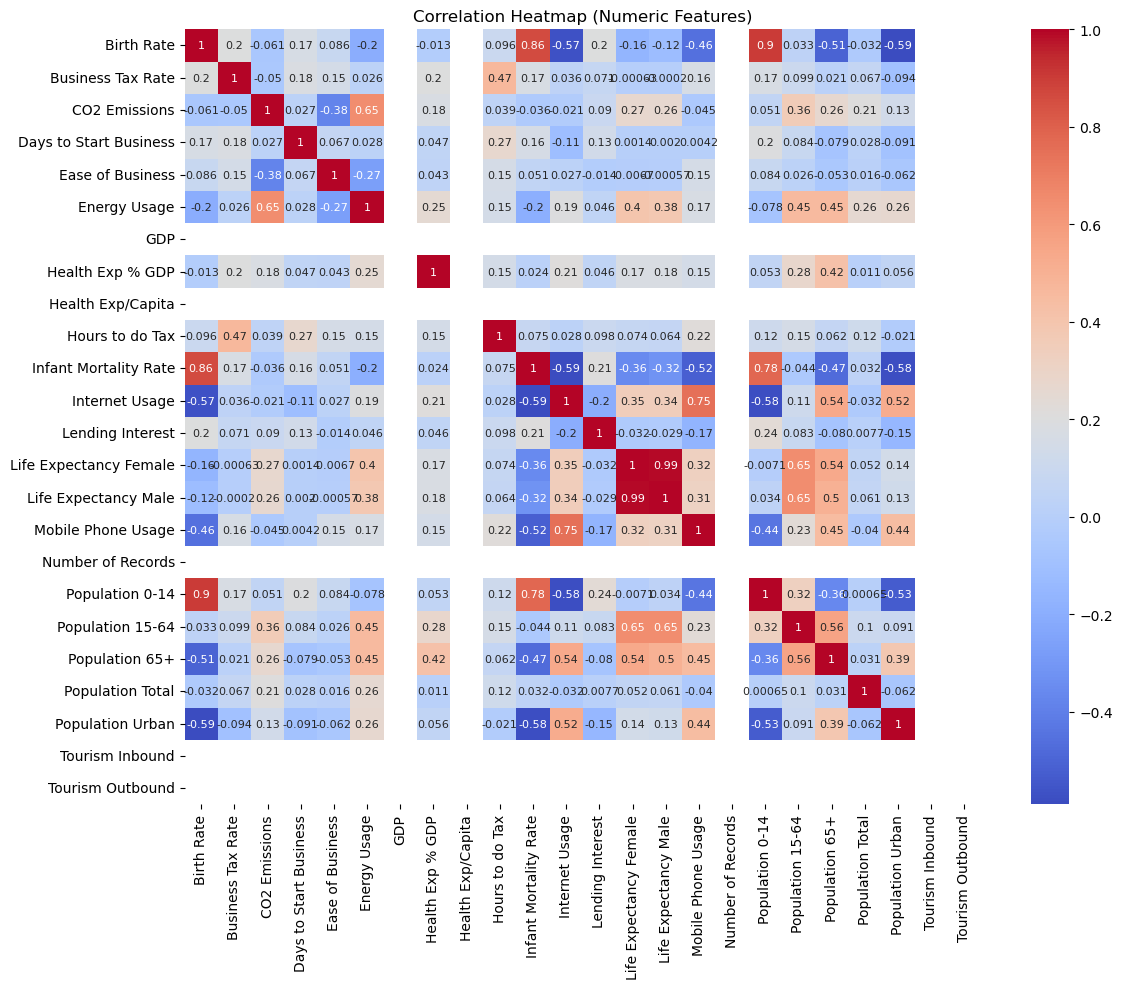

In [125]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_model.corr(), cmap='coolwarm', annot=True,annot_kws={"size": 8})
plt.title("Correlation Heatmap (Numeric Features)")
#plt.savefig("heatmap.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

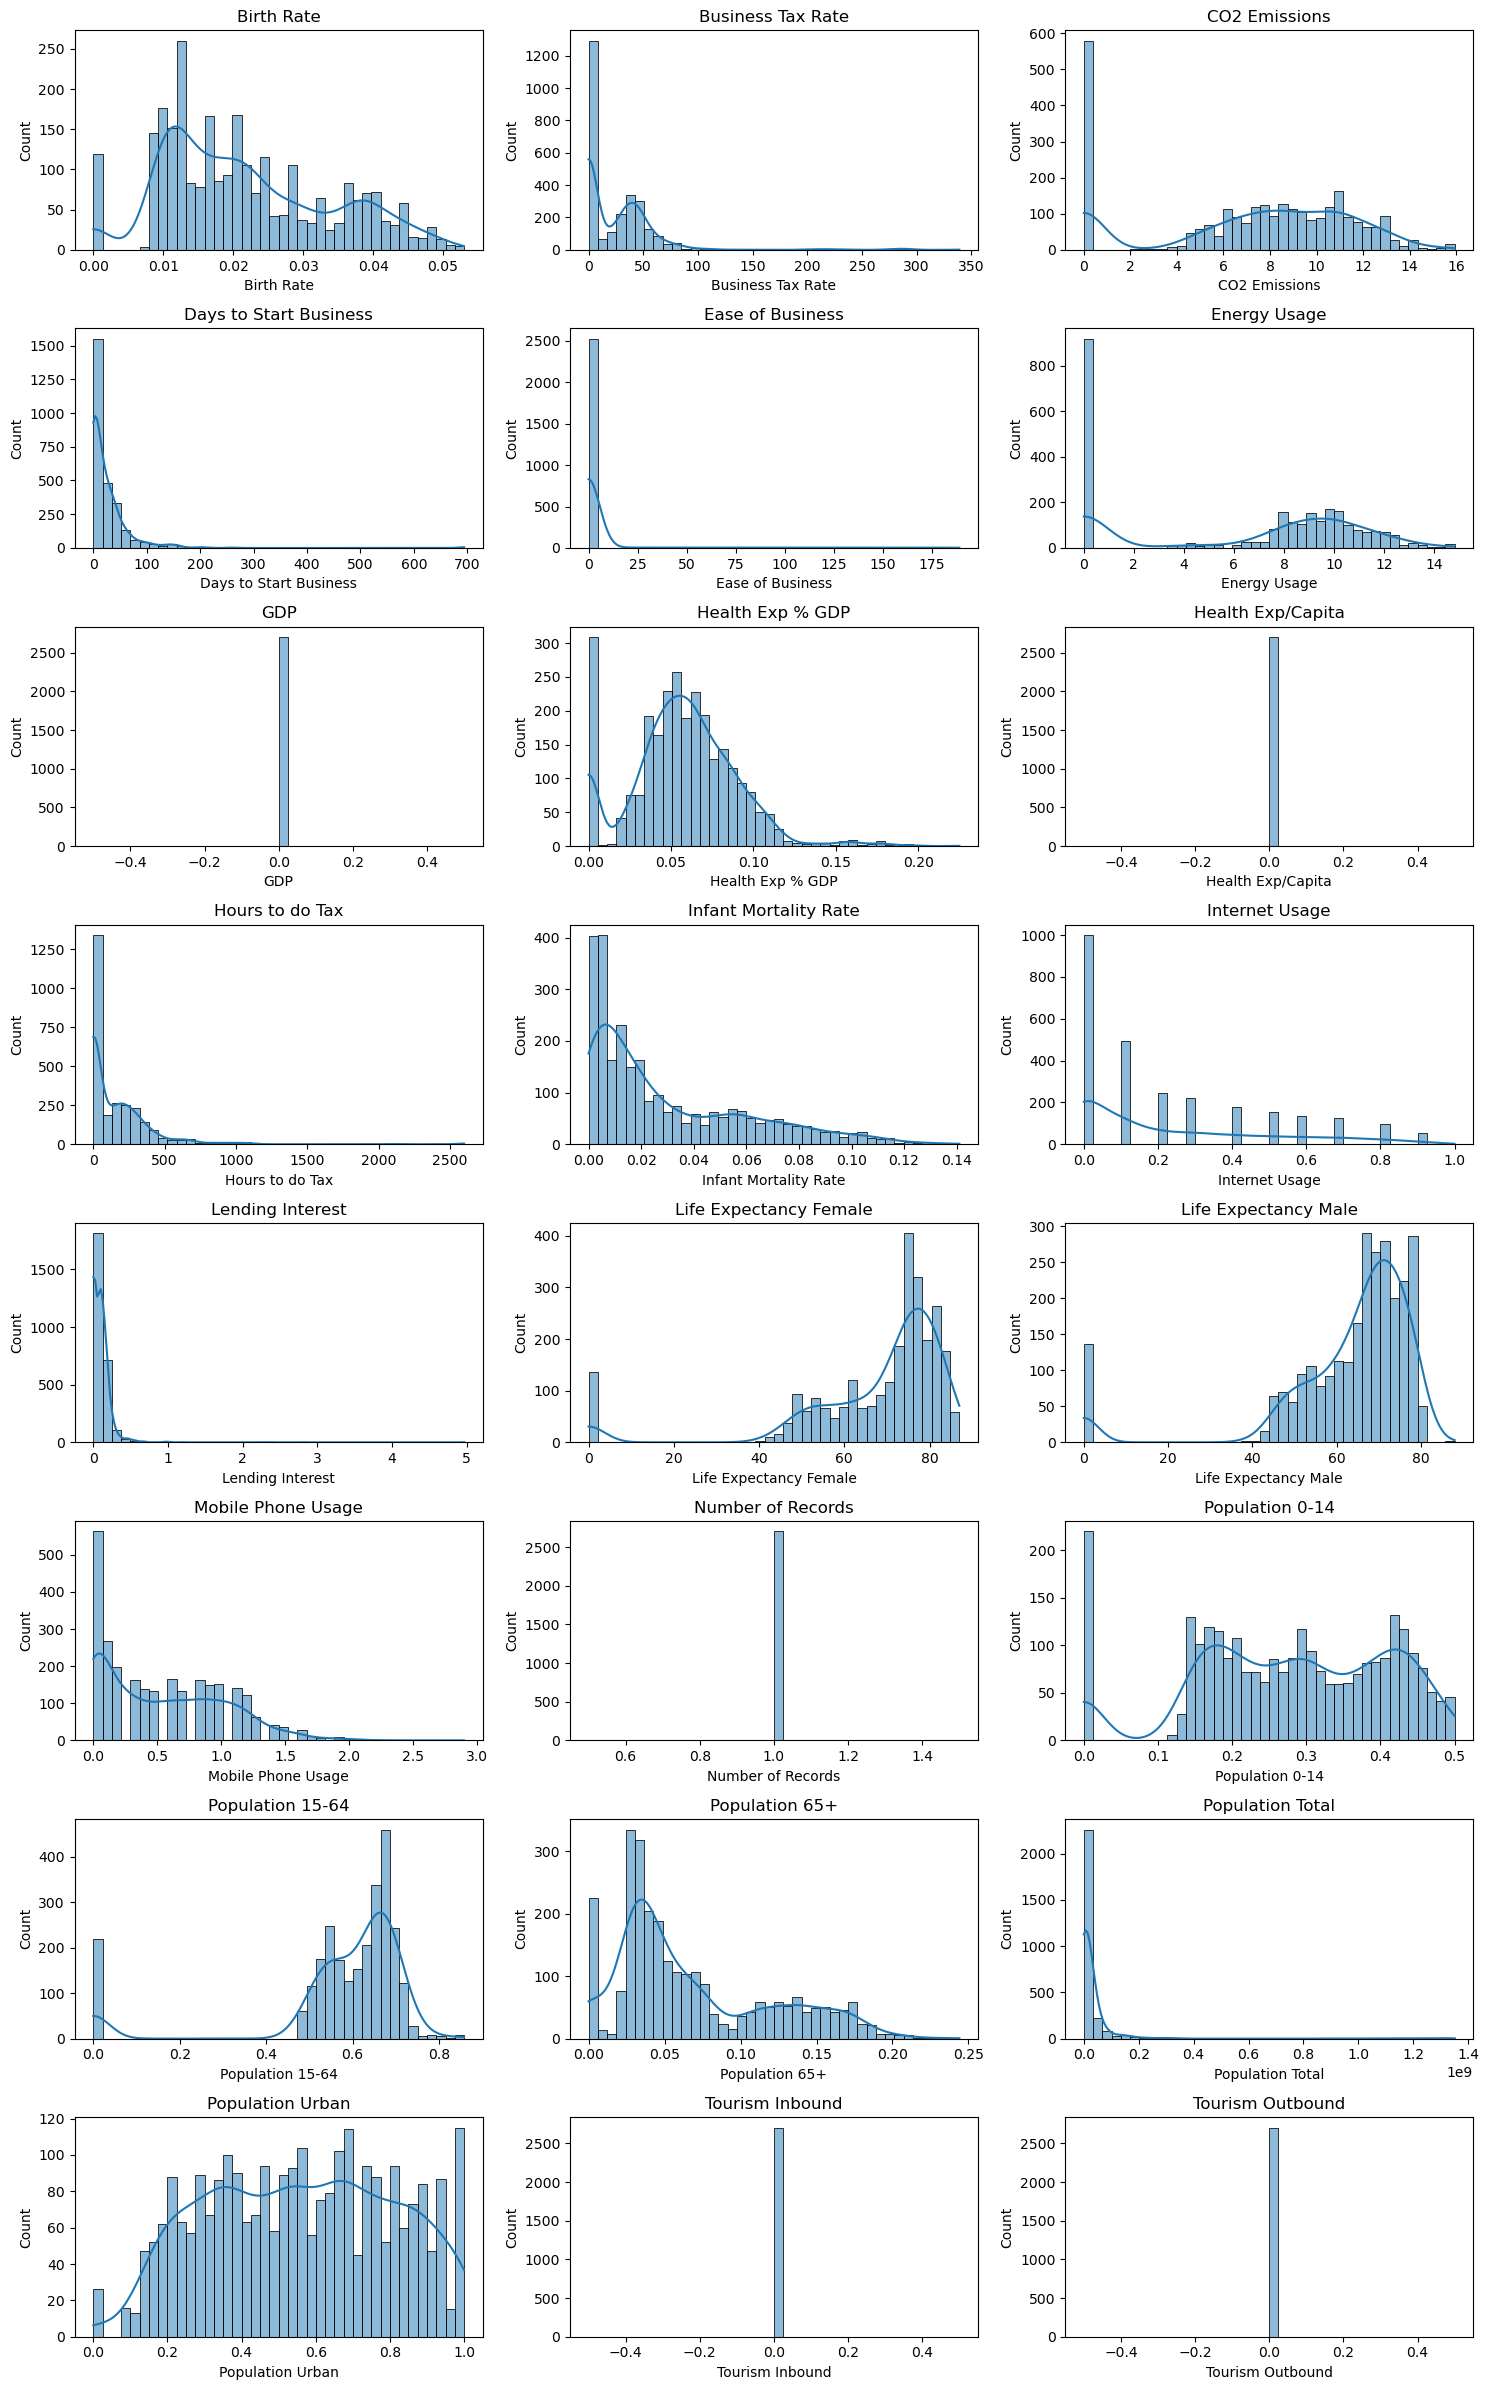

In [126]:
num_cols = df_model.select_dtypes(include = ['int64', 'float64']).columns
plot_df = df_model[num_cols]
sample_n = min(10000, plot_df.shape[0])
plot_sample = plot_df.sample(sample_n, random_state=42)

cols = 3
n = len(plot_sample.columns)
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*3))
axes = axes.flatten()
for i, col in enumerate(plot_sample.columns):
    sns.histplot(plot_sample[col], ax=axes[i], kde=True, bins=40, color='C0')
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
#plt.savefig("subplot.png", dpi=300, bbox_inches='tight')
plt.show()

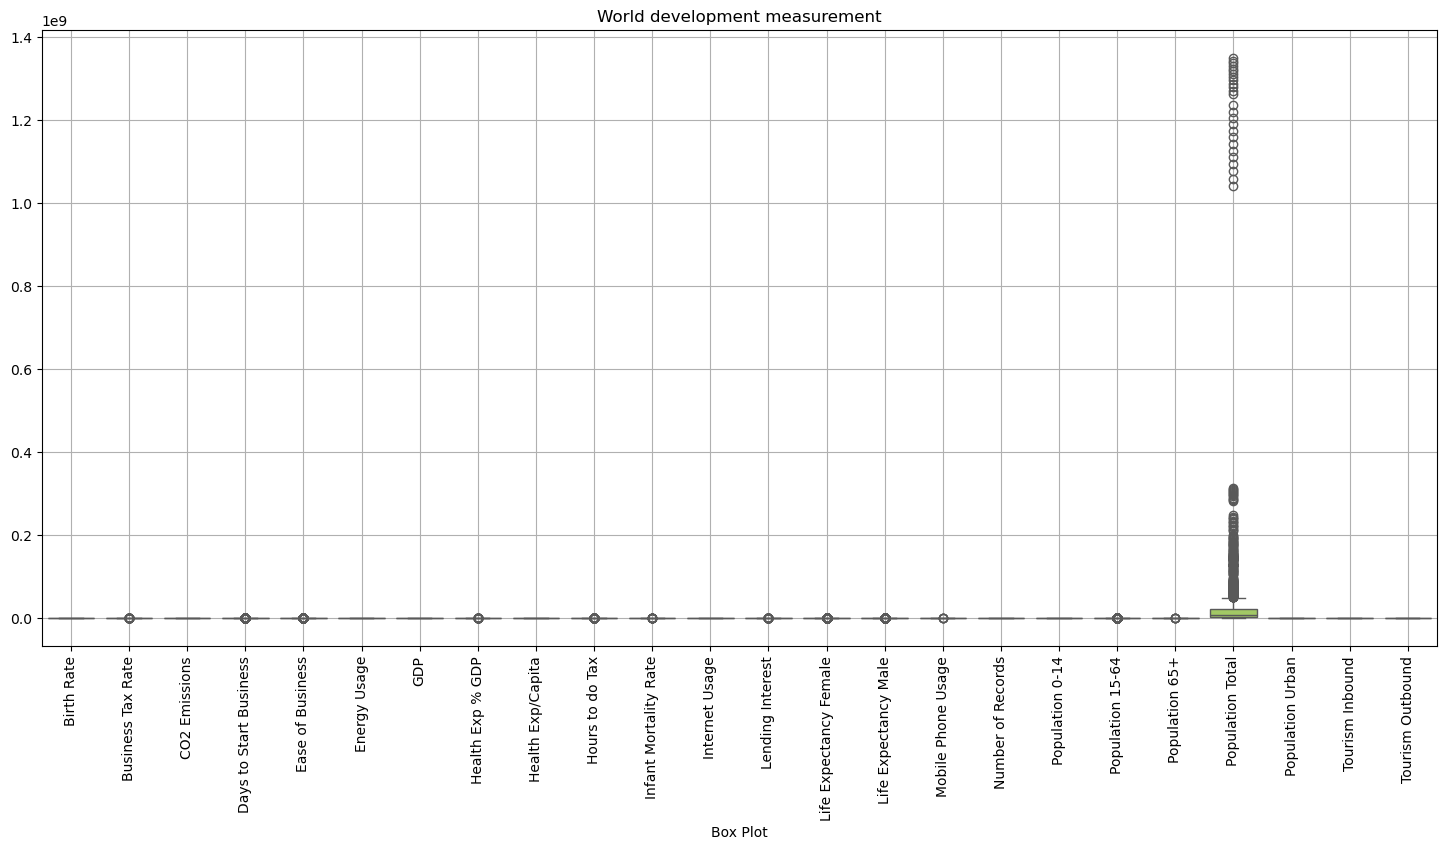

In [127]:
num_cols = df_model.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(18,8))
plt.xticks(rotation=90)
sns.boxplot(data=num_cols,palette='Set2')
plt.title("World development measurement")
plt.xlabel("Box Plot")
plt.grid(True)
# plt.savefig("boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

In [128]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Scale first
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

In [129]:
# Drop low variance features
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_filtered = selector.fit_transform(df_model)

In [130]:
## K-Means Clustering

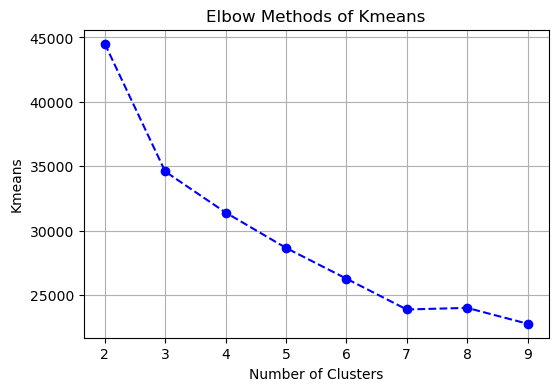

In [131]:
Kmean_data =[]

for k in range(2,10):
    km = KMeans(n_clusters= k, random_state=42)
    km.fit(X_scaled)
    Kmean_data.append(km.inertia_)

plt.figure(figsize =(6,4))
plt.plot(range(2,10),Kmean_data, marker = 'o',linestyle='--', color='b')
plt.xlabel("Number of Clusters")
plt.ylabel("Kmeans")
plt.grid(True)
plt.title("Elbow Methods of Kmeans")
#plt.savefig("Elbow_method.png", dpi=300, bbox_inches='tight')
plt.show()

In [132]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=50,
    max_iter=500,
    random_state=42
)

labels = kmeans.fit_predict(X_scaled)

In [133]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.2562140531872027


In [134]:
from sklearn.decomposition import PCA
# Apply PCA
pca = PCA(n_components=2)  # try 8–12
X_pca = pca.fit_transform(X_scaled)

In [135]:
pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])
pca_df['Cluster'] = labels
df_model['KMeans_Cluster'] = labels
pca_df['KMeans_Cluster'] = labels

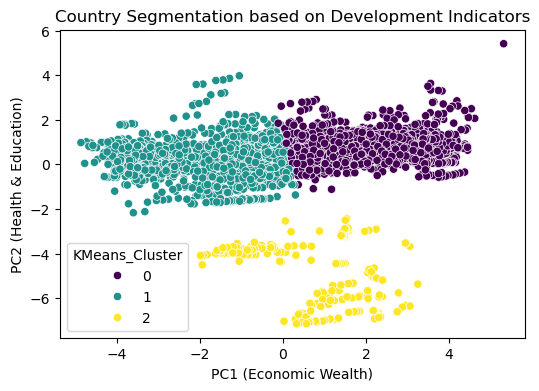

In [136]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x='PC1', y='PC2', hue='KMeans_Cluster', data=pca_df, palette='viridis')
plt.title('Country Segmentation based on Development Indicators')
plt.xlabel('PC1 (Economic Wealth)')
plt.ylabel('PC2 (Health & Education)')
#plt.savefig("PCA.png", dpi=300, bbox_inches='tight')
plt.show()

In [137]:
sil_Kmeans = silhouette_score(X_scaled,df_model['KMeans_Cluster'])
sil_Kmeans

np.float64(0.2562140531872027)

In [138]:
## Hierarchical Clustering

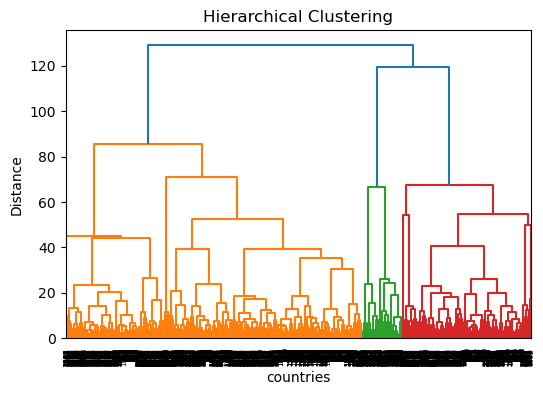

In [139]:
linked = linkage(X_scaled,method="ward")

plt.figure(figsize = (6,4))
dendrogram(linked)
plt.title("Hierarchical Clustering")
plt.xlabel('countries')
plt.ylabel('Distance')
plt.show()

In [140]:
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
df_model['Hierarchical_Cluster'] = hc.fit_predict(X_scaled)

df_model.groupby('Hierarchical_Cluster').mean()

,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,...,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound,KMeans_Cluster
Hierarchical_Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.017043,22.338982,8.454790,19.897629,3.000578,7.935523,0.0,0.061465,0.0,157.094853,...,0.668190,1.0,0.251504,0.657767,0.090740,4.159375e+07,0.633637,0.0,0.0,0.769809
1,0.037074,39.894094,5.628996,45.217450,15.997315,4.050077,0.0,0.055974,0.0,204.181208,...,0.267114,1.0,0.423624,0.543464,0.032878,1.760069e+07,0.346821,0.0,0.0,0.030872
2,0.007091,5.803043,2.490468,2.734783,1.939130,0.565248,0.0,0.024835,0.0,17.378261,...,0.488696,1.0,0.010126,0.028557,0.004796,1.409327e+05,0.668026,0.0,0.0,2.000000


In [141]:
sil_hc = silhouette_score(X_scaled, df_model["Hierarchical_Cluster"])
sil_hc

np.float64(0.2504407900155618)

In [142]:
## DBSCAN Clustering

In [143]:
dbscan = DBSCAN(eps=1.2, min_samples=5)
df_model['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

In [144]:
df_model['DBSCAN_Cluster'].value_counts

<bound method IndexOpsMixin.value_counts of 0        0
1       -1
2        1
3        1
4        1
        ..
2699    15
2700    -1
2701    -1
2702    -1
2703    17
Name: DBSCAN_Cluster, Length: 2704, dtype: int64>

In [145]:
mask = df_model['DBSCAN_Cluster'] != -1

if mask.sum() > 1:
    sil_dbscan = silhouette_score(
        X_scaled[mask],
        df_model.loc[mask, 'DBSCAN_Cluster']
    )
    sil_dbscan
else:
    sil_dbscan = "Not enough clusters"

In [146]:
sil_dbscan

np.float64(0.05360138010933682)

In [147]:
cluster_features = df_model.columns
df_model.groupby('KMeans_Cluster')[cluster_features].mean()

,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,...,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound,KMeans_Cluster,Hierarchical_Cluster,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.033179,31.123750,6.689309,38.831250,9.641964,4.872952,0.0,0.055299,0.0,166.915179,...,0.401975,0.561426,0.036592,3.290314e+07,0.371776,0.0,0.0,0.0,0.644643,14.106250
1,0.014716,24.731610,8.360346,18.167651,4.658050,8.330960,0.0,0.063544,0.0,174.879616,...,0.221742,0.674566,0.103693,3.558093e+07,0.692431,0.0,0.0,1.0,0.016987,13.076809
2,0.007091,5.803043,2.490468,2.734783,1.939130,0.565248,0.0,0.024835,0.0,17.378261,...,0.010126,0.028557,0.004796,1.409327e+05,0.668026,0.0,0.0,2.0,2.000000,12.195652


In [148]:
df_model.groupby('Hierarchical_Cluster')[cluster_features].mean()
df_model[df_model['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster')[cluster_features].mean()

,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,...,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound,KMeans_Cluster,Hierarchical_Cluster,DBSCAN_Cluster
DBSCAN_Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.021355,1.834058,10.518203,13.822464,0.000000,9.594267,0.0,0.043203,0.0,7.557971,...,0.310620,0.644612,0.044764,1.897087e+07,0.625373,0.0,0.0,0.583333,0.000000,0.0
1,0.033732,12.393734,6.915009,16.809524,0.000000,4.109370,0.0,0.052506,0.0,62.070175,...,0.403965,0.557113,0.038922,1.100052e+07,0.317033,0.0,0.0,0.117794,0.654135,1.0
2,0.033400,0.000000,7.320859,0.000000,0.000000,7.358431,0.0,0.034200,0.0,0.000000,...,0.401600,0.540400,0.057800,1.285818e+06,0.815200,0.0,0.0,0.000000,1.000000,2.0
3,0.047308,0.000000,6.385617,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.479154,0.493231,0.027462,1.040570e+07,0.330923,0.0,0.0,0.000000,1.000000,3.0
4,0.023600,0.000000,12.838585,15.200000,0.000000,11.655461,0.0,0.085800,0.0,0.000000,...,0.320600,0.642200,0.037600,4.562943e+07,0.579200,0.0,0.0,0.000000,0.000000,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,0.021600,39.640000,6.830950,37.000000,0.000000,0.000000,0.0,0.058800,0.0,282.400000,...,0.348800,0.614000,0.037400,7.479242e+05,0.303600,0.0,0.0,0.000000,0.000000,88.0
89,0.015000,53.880000,8.860994,52.200000,0.000000,8.224853,0.0,0.083800,0.0,323.200000,...,0.230200,0.632000,0.137400,3.349982e+06,0.940000,0.0,0.0,1.000000,0.000000,89.0
90,0.028000,19.500000,2.252831,46.600000,0.000000,0.599146,0.0,0.099400,0.0,327.600000,...,0.380600,0.576000,0.043400,1.991259e+06,0.243000,0.0,0.0,0.000000,1.000000,90.0


In [149]:
## Guassian Model

In [150]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

In [151]:
sil_gmm  = silhouette_score(X_scaled, gmm_labels)
sil_gmm

np.float64(0.2471003037299901)

In [152]:
#Guassian Model with PCA Visualisation

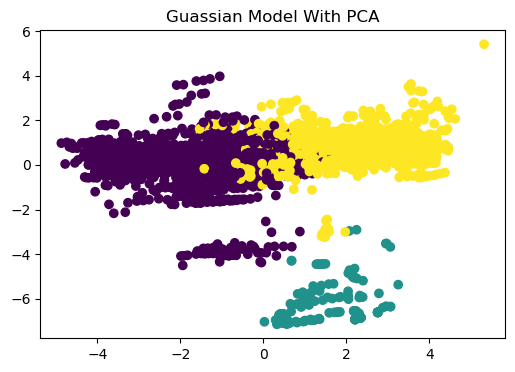

In [153]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=gmm_labels, cmap="viridis")
plt.title("Guassian Model With PCA")
#plt.savefig("Guassian_Model_PCA.png", dpi=300, bbox_inches='tight')
plt.show()

In [154]:
def run_spectral_clustering(X, n_clusters=3, n_neighbors=15):
    from sklearn.cluster import SpectralClustering
    from sklearn.metrics import silhouette_score

    model = SpectralClustering(
        n_clusters=n_clusters,
        affinity="nearest_neighbors",
        n_neighbors=25,
        random_state=42
    )

    labels = model.fit_predict(X)

    # Safe silhouette calculation
    if len(set(labels)) > 1:
        score = silhouette_score(X, labels)
    else:
        score = -1

    return labels, score


# Usage
spectral_labels, spectral_score = run_spectral_clustering(X_scaled)

print(f"Spectral Clustering Silhouette Score: {spectral_score:.4f}")

Spectral Clustering Silhouette Score: 0.2449


In [155]:
from sklearn.cluster import KMeans

best_score = -1
best_k = None

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    
    print(f"k={k}, silhouette={score:.3f}")
    
    if score > best_score:
        best_score = score
        best_k = k

best_k, best_score

## This finds the best number of clusters
## Based on objective metric

k=2, silhouette=0.406
k=3, silhouette=0.256
k=4, silhouette=0.195
k=5, silhouette=0.214
k=6, silhouette=0.225
k=7, silhouette=0.231


(2, np.float64(0.40643139360658387))

In [156]:
#Train final tuned KMeans

In [157]:
best_kmeans = KMeans(n_clusters=3,random_state=42)
kmeans_labels = best_kmeans.fit_predict(X_scaled)

In [158]:
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
sil_kmeans

np.float64(0.25645772882369733)

In [159]:
## MODEL COMPARISON

In [160]:
import pandas as pd

result = pd.DataFrame({
    "Model": ["KMeans", "Hierarchical", "DBSCAN", "Gaussian Mixture", "Spectral"],
    "Silhouette_Score": [
        sil_kmeans,
        sil_hc,
        sil_dbscan if isinstance(sil_dbscan, float) else -1,  # better than 0 (invalid case)
        sil_gmm,
        spectral_score
    ]
})
print(result)

              Model  Silhouette_Score
0            KMeans          0.256458
1      Hierarchical          0.250441
2            DBSCAN          0.053601
3  Gaussian Mixture          0.247100
4          Spectral          0.244918


In [161]:
# Find best model
best_row = result.loc[result["Silhouette_Score"].idxmax()]

best_model = best_row["Model"]
best_score = best_row["Silhouette_Score"]

print("Best Model:", best_model)
print("Best Score:", best_score)

Best Model: KMeans
Best Score: 0.25645772882369733


In [162]:
## Deployment 

In [166]:
# Import the model class
from world_development_model import WorldDevelopmentClusteringModel

model = WorldDevelopmentClusteringModel(n_clusters=3, random_state=42)
model.fit(df_model)
labels = model.predict(df_model)

# Save the model to disk
model_path = model.save('world_development_kmeans.pkl')

  Model trained successfully!
  Silhouette Score: 0.2768
 Model saved to: world_development_kmeans.pkl
